# 1D-CNN Classifier. Training and saving.

Simple model creation and weights saving notebook \
This uses the created modules for code simplicity and enables log reading

In [1]:
import sys
print(sys.executable)

import config
import dataset
import utils
import models
import training
import checkpoint

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Scripts\python.exe


Settings are read from a yaml configuration file \
You can configure model, training and dataset parameters for experiment iterations

In [2]:
settings = config.load_config('base_config.yaml')
settings

Reading config yaml


{'model': {'name': 'LiteratureCNN',
  'kernel_size': 3,
  'stride': 1,
  'schedule': 'scheduler',
  'optimizer': 'adamw',
  'loss_function': 'cross-entropy'},
 'training': {'batch_size': 64,
  'epochs': 43,
  'learning_rate': 0.001,
  'seed': 42},
 'dataset': {'filename': 'C:\\Users\\nxf93627\\PQD Classifier\\data\\16pqd_480pattern_50hz_10cycle_noNoise.mat',
  'seed_random': 42,
  'test_percentage': 0.1}}

Dataset is loaded, splitted and encoded, then a few settings are added to configuration dictionary

In [3]:
X_train, Y_train, X_test, Y_test, encoder, metadata = dataset.loadMatlabDataset(settings['dataset'])

model_cfg = settings['model']
model_cfg.update({'input_shape': (metadata['observations'], 1), 'outputs': metadata['classes']})
model_cfg

Loading dataset from C:\Users\nxf93627\PQD Classifier\data\16pqd_480pattern_50hz_10cycle_noNoise.mat
Successfully read 7680 samples
Encoding labels with OneHot
Successfully encoded 16 categories
Splitted training (0.9) and testing sets (0.1)


{'name': 'LiteratureCNN',
 'kernel_size': 3,
 'stride': 1,
 'schedule': 'scheduler',
 'optimizer': 'adamw',
 'loss_function': 'cross-entropy',
 'input_shape': (640, 1),
 'outputs': 16}

Experiment directory is created based on date and time timestamp

In [4]:
experiment_path = utils.set_timestamp_dir()
config.log_config(settings, experiment_path)

Successfully exported yaml config


Model is build, it creates a sequential architecture and compiles it

In [5]:
model = models.build_model(settings['model'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 638, 32)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 636, 32)             │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 634, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 632, 64)             │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 630, 64)             │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 628, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 626, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 624, 128)            │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           2,064 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 164,784 (643.69 KB)

 Trainable params: 164,272 (641.69 KB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
model = training.train(model, settings['training'], X_train, Y_train, X_test, Y_test)

lr = 0.001
Epoch 1/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - accuracy: 0.6464 - loss: 1.0202 - val_accuracy: 0.2018 - val_loss: 2.7393 - learning_rate: 0.0010
lr = 0.001
Epoch 2/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.7724 - loss: 0.5741 - val_accuracy: 0.1823 - val_loss: 2.7430 - learning_rate: 0.0010
lr = 0.001
Epoch 3/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.7827 - loss: 0.5299 - val_accuracy: 0.2305 - val_loss: 2.4942 - learning_rate: 0.0010
lr = 0.001
Epoch 4/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - accuracy: 0.8041 - loss: 0.4685 - val_accuracy: 0.2891 - val_loss: 2.1276 - learning_rate: 0.0010
lr = 0.001
Epoch 5/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.8138 - loss: 0.4338 - val_accuracy: 0.5273 - val_loss: 1.2597 - learning_rate: 0.0010
lr = 0.001
Epoch 6/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 0.8158 - loss: 0.4236 - val_accuracy: 0.2917 - val_loss: 3.7971 - learning_rate: 0.0010
lr =

After training, model is evaluated with test split \
Then Macro F1 measures are calculated, including precision, accuracy, recall and weighted F1

Evaluating Keras model
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
        Metric  Value
0     Accuracy   0.85
1     Macro F1   0.85
2  Weighted F1   0.85
                        precision  recall  f1-score  support
Flicker                      0.92    1.00      0.96     48.0
Flicker+Harmonics            1.00    1.00      1.00     48.0
Flicker+Sag                  1.00    0.98      0.99     48.0
Flicker+Swell                1.00    0.94      0.97     48.0
Harmonics                    0.92    1.00      0.96     48.0
Impulsive Transient          1.00    0.88      0.93     48.0
Interruption                 0.48    0.48      0.48     48.0
Interruption+Harmonics       0.54    0.60      0.57     48.0
Normal                       0.86    1.00      0.92     48.0
Notch                        0.94    1.00      0.97     48.0
Oscillatory transient        1.00    1.00      1.00     48.0
Sag                          0.44    0.40      0.42     48.0
Sag+Harmonics                0.54    0.42      0.47     

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Successfully wrote 'confusion matrix.png'


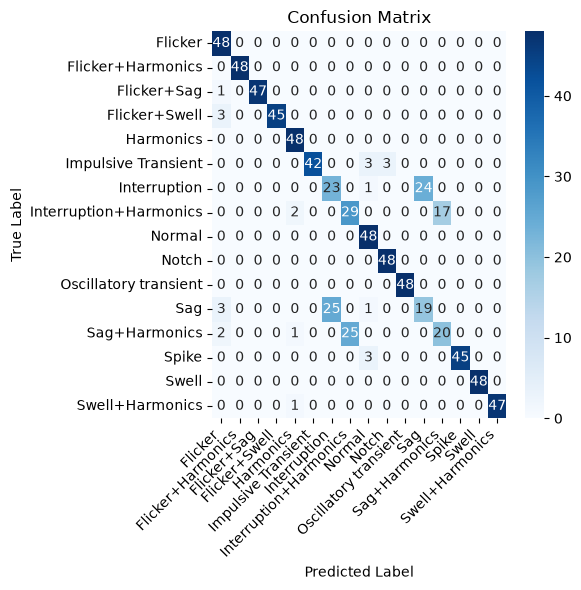

In [7]:
training.evaluate(model, X_test, Y_test, metadata['categories'], experiment_path)

Model is finally saved under experiment directory path

In [8]:
checkpoint.save_model_weights(model, experiment_path)

Weights saved to C:\Users\nxf93627\Projects\PQD-Classifier\models\run_08_17-11_48


Optional, is not necessary as long as model is build with models.build()

In [9]:
import json

model_json = model.to_json()
with open(experiment_path / 'model.json', "w") as json_file:
    json_file.write(json.dumps(json.loads(model_json), indent=4))